<a href="https://colab.research.google.com/github/duck66-in/Model_learning/blob/main/ClassificationTst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as mp

In [ ]:
keras.utils.set_random_seed(42)

In [ ]:
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")


In [ ]:
df.shape

(303, 14)

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [ ]:
df.target.value_counts(normalize=True, dropna=False)

,proportion
target,
0,0.726073
1,0.273927


In [ ]:
categorical_varaibles = ['sex', 'cp', 'fbs', 'restecg','exang', 'ca', 'thal']
numerics = ['age', 'trestbps','chol', 'thalach', 'oldpeak', 'slope']

PreProcessing..

In [ ]:
df = pd.get_dummies(df, columns = categorical_varaibles)


In [ ]:
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [ ]:
test_df = df.sample(frac=0.2,random_state=42)
train_df= df.drop(test_df.index)

In [ ]:
train_df.shape

(242, 30)

In [ ]:
test_df.shape

(61, 30)

In [ ]:
means = train_df[numerics].mean()
sd = train_df[numerics].std()
means

,0
age,54.268595
trestbps,131.995868
chol,246.512397
thalach,149.805785
oldpeak,1.032645
slope,1.590909


In [ ]:
train_df[numerics] = (train_df[numerics] - means) / sd

In [ ]:
test_df[numerics] = (test_df[numerics] - means) / sd

In [ ]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [ ]:
train = train_df.to_numpy()
test = test_df.to_numpy()

In [ ]:
train_X = np.delete(train, 6, axis=1)
test_X = np.delete(test, 6, axis=1)

In [ ]:
train_X.shape, test_X.shape

((242, 29), (61, 29))

In [ ]:
train_Y = train[:,6]
test_Y = test[:,6]

In [ ]:
train_Y.shape , test_Y.shape

((242,), (61,))

Model building ...

In [ ]:
num_cols = train_X.shape[1]
input = keras.Input(shape = (num_cols,))


In [ ]:
num_cols = train_X.shape[1]
input = keras.Input(shape = (num_cols,))


In [ ]:

h = keras.layers.Dense(16, activation="relu",name="hidden")(input)
output = keras.layers.Dense(1, activation="sigmoid",name="output")(h)
model = keras.Model(input, output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

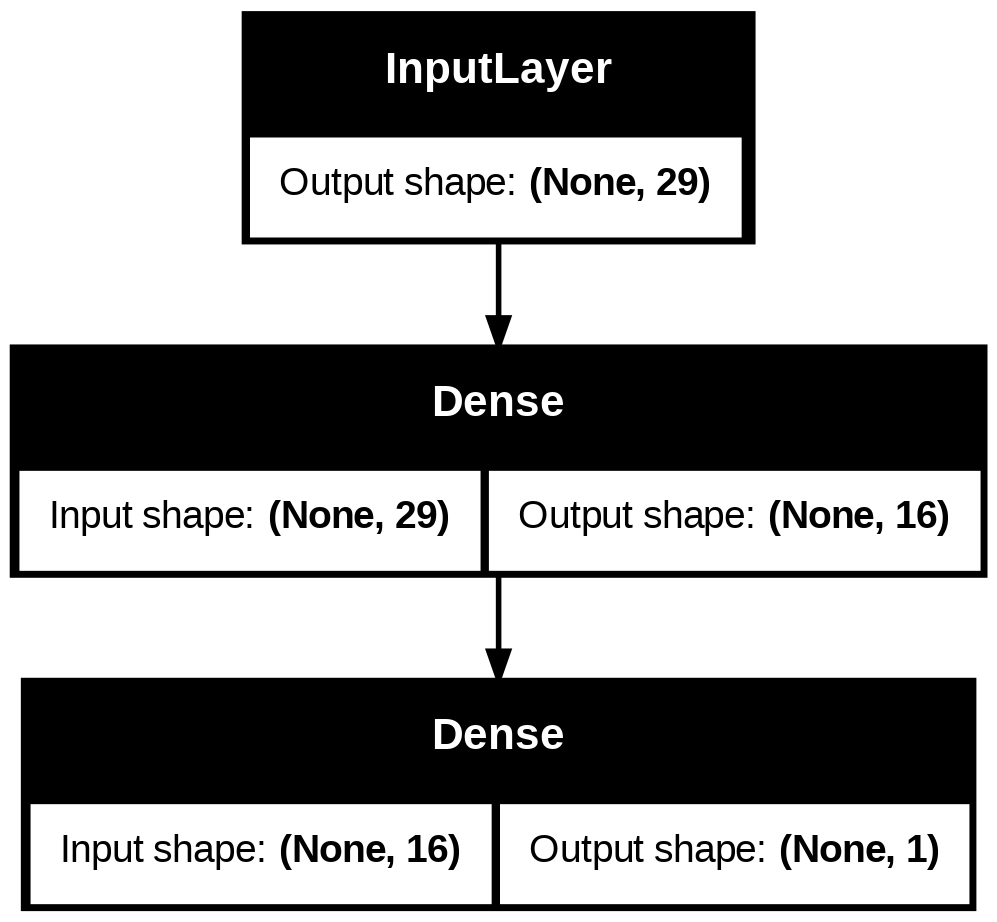

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
model.compile(optimizer="adam", loss="binary_crossentropy",metrics=["accuracy"])

In [ ]:
print(train_X.dtype)

object


In [ ]:
train_X = train_X.astype('float32')
train_Y = train_Y.astype('float32')
history = model.fit(train_X, train_Y, epochs= 300, batch_size =32, verbose=1, validation_split = 0.2)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.3981 - loss: 0.8023 - val_accuracy: 0.4898 - val_loss: 0.7203
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5096 - loss: 0.7303 - val_accuracy: 0.6122 - val_loss: 0.6773
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6285 - loss: 0.6724 - val_accuracy: 0.6327 - val_loss: 0.6410
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6666 - loss: 0.6230 - val_accuracy: 0.6735 - val_loss: 0.6112
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7149 - loss: 0.5817 - val_accuracy: 0.7143 - val_loss: 0.5866
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7681 - loss: 0.5476 - val_accuracy: 0.7551 - val_loss: 0.5662
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7812 - loss: 0.5192 - val_accuracy: 0.7347 - val_loss: 0.5493
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7863 - loss: 0.4949 - val_accuracy: 0.7347 - val_loss:

In [78]:
history_dic = history.history
history_dic.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

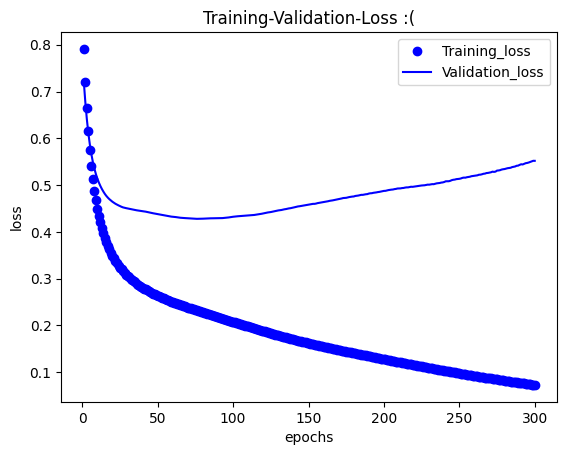

In [85]:
loss_values = history_dic["loss"]
val_loss_values = history_dic["val_loss"]
epochs = range(1,len(loss_values)+1)
mp.plot(epochs,loss_values,"bo",label="Training_loss")
mp.plot(epochs,val_loss_values,"b",label="Validation_loss")
mp.title("Training-Validation-Loss :(")
mp.xlabel("epochs")
mp.ylabel("loss")
mp.legend()
mp.show()

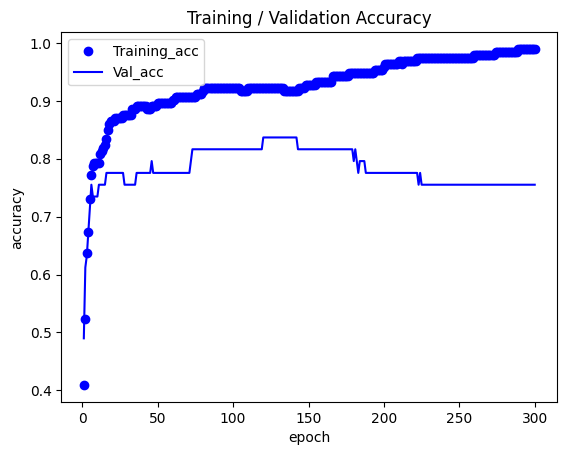

In [87]:
mp.clf()
acc= history_dic["accuracy"]
val_acc  = history_dic["val_accuracy"]
mp.plot(epochs,acc,"bo",label="Training_acc")
mp.plot(epochs,val_acc,"b",label="Val_acc")
mp.title("Training / Validation Accuracy")
mp.xlabel("epoch")
mp.ylabel("accuracy")
mp.legend()
mp.show()



In [89]:
#evaluate
test_X = test_X.astype('float32')
test_Y = test_Y.astype('float32')
model.evaluate(test_X,test_Y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8277 - loss: 0.5836


[0.5507304668426514, 0.8196721076965332]